In [1]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 
import os

In [9]:
mypath_cache = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/cache-results/output-mobilenet_v3-M01-1000-sort'
mypath_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/origin-results/output-mobilenet_v3-O01'

def gen_values(mypath):
    values = {}
    values_acc = {}
    for (dir_path, dir_names, file_names) in walk(mypath):
        for filename in file_names:
            if("output" not in filename):
                with open(os.path.join(dir_path, filename), 'r') as f:
                    best = 100000
                    count = 0
                    s = 0
                    for l in f:
                        result = json.loads(l)
                        task = result['i'][0][0]
                        r = sum(result['r'][0])/len(result['r'][0])
                        if(r > 1000 and count == 0):
                            continue
                        if(task not in values):
                            values[task] = []
                            values_acc[task] = []
                        if(r < best):
                            best = r
                        values[task].append(best)
                        if(r < 1000):
                            s += r
                        values_acc[task].append(s)
                        count += 1
    return values, values_acc

values_, values_acc_ = gen_values(mypath_origin)
values, values_acc = gen_values(mypath_cache)

In [10]:
for idx, task in enumerate(values_):
    if(task not in values):
        print(task)

In [11]:
for idx, task in enumerate(values):
    if(task not in values_):
        print(task)

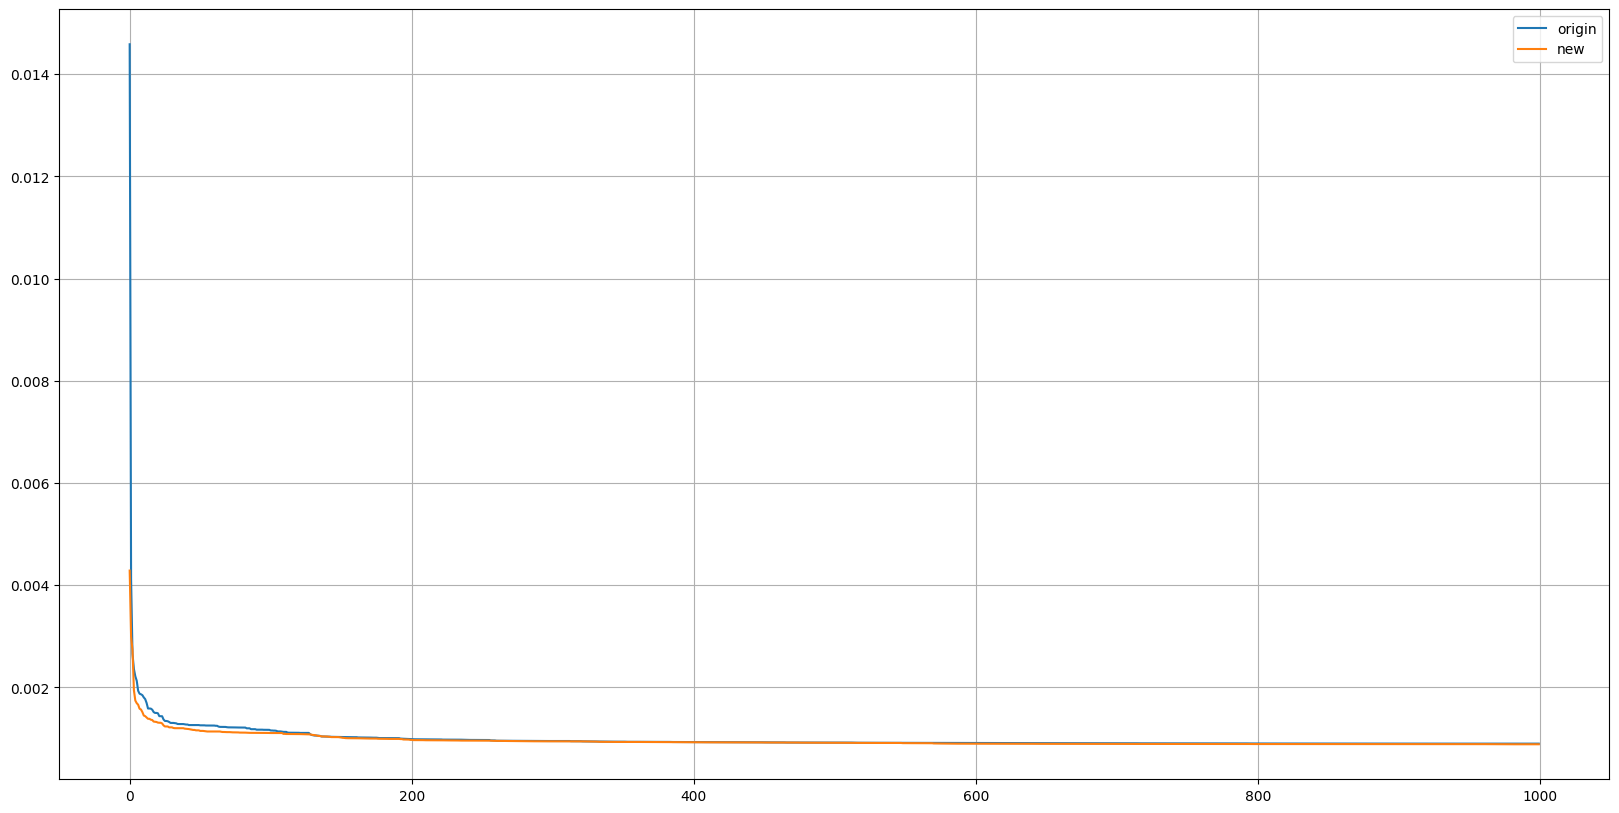

In [12]:
result_n = np.zeros(1000)
result_cn = np.zeros(1000)
result_o = np.zeros(1000)
result_co = np.zeros(1000)

for idx, task in enumerate(values_):
    if(len(values[task])):
        for idx, value in enumerate(values[task][:1000]):
            result_n[idx] += value
            result_cn[idx] += 1
        for idx, value in enumerate(values_[task][:1000]):
            result_o[idx] += value
            result_co[idx] += 1

#for idx, value in enumerate(result_n):
#    result_n[idx] = result_n[idx] / result_cn[idx]
#for idx, value in enumerate(result_o):
#    result_o[idx] = result_o[idx] / result_co[idx]
    
plt.figure(figsize=(20, 10))
plt.plot(result_o, label="origin")
plt.plot(result_n, label="new")
plt.grid()
plt.legend()

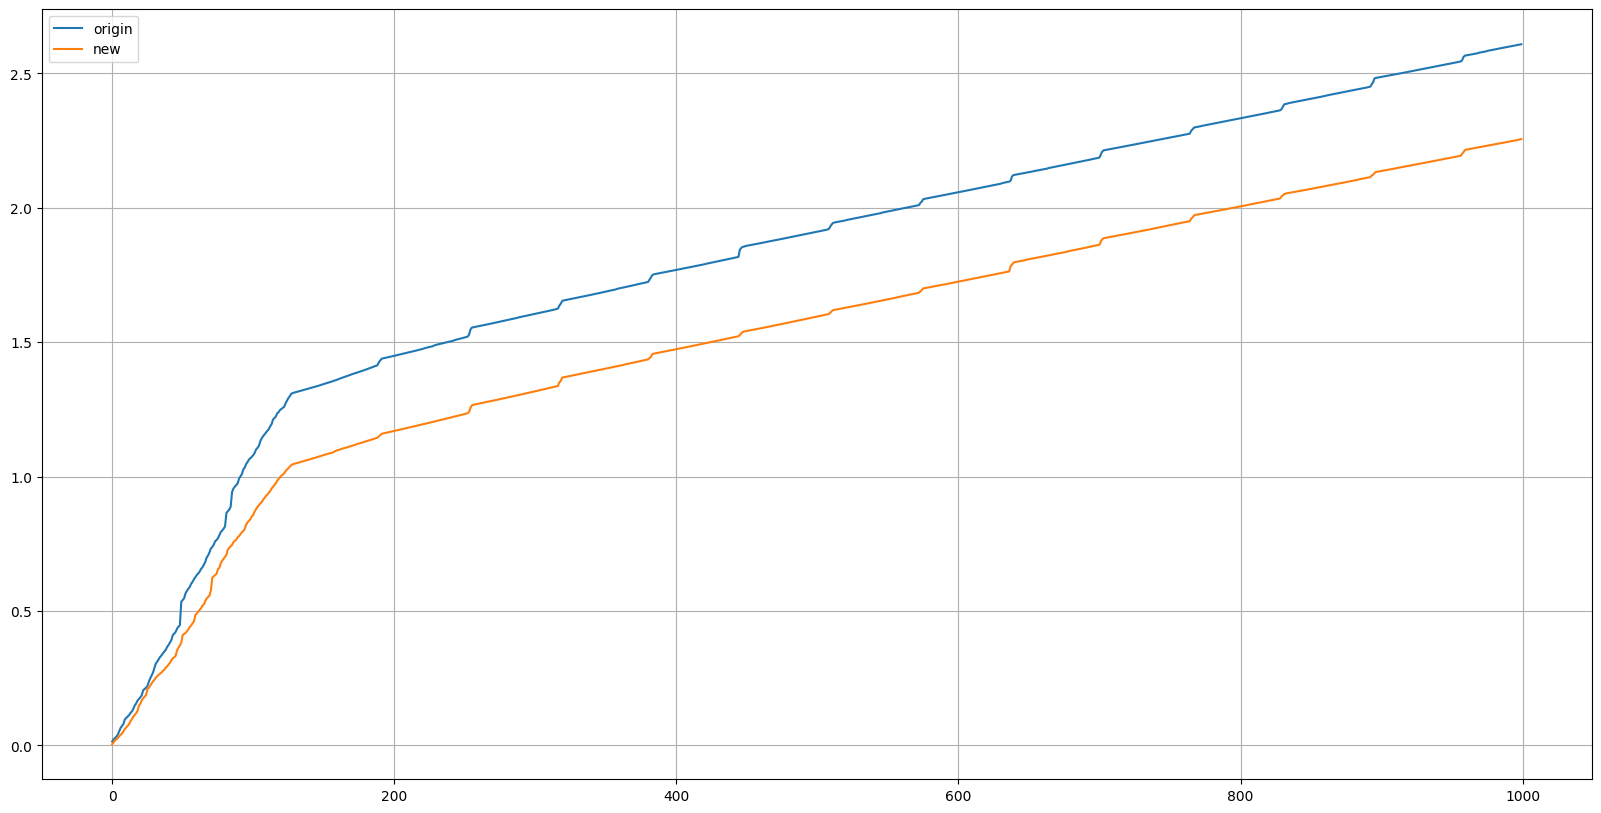

In [13]:
result_n = np.zeros(1000)
result_cn = np.zeros(1000)
result_o = np.zeros(1000)
result_co = np.zeros(1000)

for idx, task in enumerate(values_acc_):
    if(len(values_acc[task]) == 1000):
        for idx, value in enumerate(values_acc[task][:1000]):
            result_n[idx] += value
            result_cn[idx] += 1
        for idx, value in enumerate(values_acc_[task][:1000]):
            result_o[idx] += value
            result_co[idx] += 1

#for idx, value in enumerate(result_n):
#    result_n[idx] = result_n[idx] / result_cn[idx]
#for idx, value in enumerate(result_o):
#    result_o[idx] = result_o[idx] / result_co[idx]
    
plt.figure(figsize=(20, 10))
plt.plot(result_o, label="origin")
plt.plot(result_n, label="new")
plt.grid()
plt.legend()